<a href="https://colab.research.google.com/github/Harshini-Suresha/Plant_classification/blob/main/CNN_Image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

In [ ]:
#connect to google drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
#define the path and split your data into training and validation split
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "/content/gdrive/MyDrive/Plant_photos")
ds_train = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/gdrive/MyDrive/Plant_photos",
    validation_split=0.2,
    subset="training",
    seed=123)

ds_validation = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/gdrive/MyDrive/Plant_photos",
    validation_split=0.2,
    subset="validation",
    seed=123)



Found 3890 files belonging to 5 classes.
Found 3890 files belonging to 5 classes.
Using 3112 files for training.
Found 3890 files belonging to 5 classes.
Using 778 files for validation.


In [ ]:
# define the batch size and print the image labels
import tensorflow_datasets as tfds
batch_size = 64
dataset_name = dataset
class_names = dataset.class_names
print(class_names)

['ArecaNut', 'Bird of Paradise ', 'Cast Iron Plant ', 'Date palm', 'Monstera Deliciosa ']


In [ ]:
#resize your images and standardalise your data to make it for a neural data
#Standardalise your data
size = (1024,1024)
ds_train = ds_train.map(lambda image, label: (tf.image.resize(image, size), label))
ds_val = ds_validation.map(lambda image, label: (tf.image.resize(image, size), label))

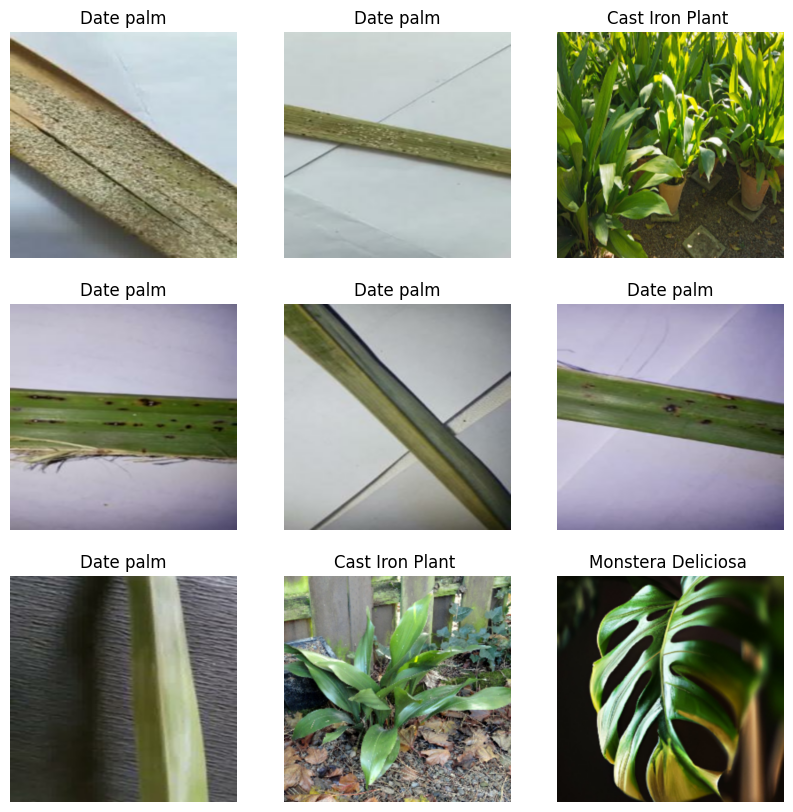

In [ ]:
# Display the first 9 images
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for images, labels in ds_train.take(1):
  for i in range (9):
    ax = plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")


In [ ]:
#do further preprocessing to increase the instances of images
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

image = Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(height_factor=(-0.2,-0.3),width_factor=(-0.2,-0.3),interpolation='bilinear'),
        layers.RandomContrast(factor=0.1),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    ],
    name="image",
)



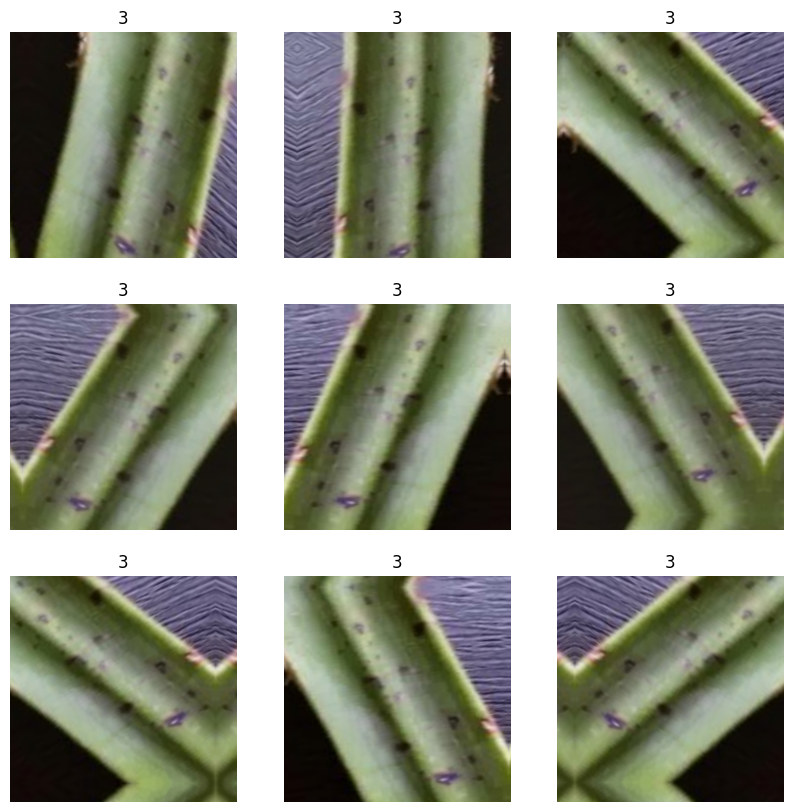

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

#define the augmentation model
image_augmentation = Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(height_factor=(-0.2,-0.3),width_factor=(-0.2,-0.3),interpolation='bilinear'),
        layers.RandomContrast(factor=0.1),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    ],
    name="image",
)

# Define helper functions if not already done so
def f(x):
  return np.int32(x)
f2 = np.vectorize(f)

for images, labels in ds_train.take(1):
  plt.figure(figsize=(10, 10))
  for i in range(9):
      #Get an image from the dataset
      first_image = images[0]
      ax = plt.subplot(3, 3, i + 1)
      #Augment the image using the sequential model
      augmented_image = image_augmentation(tf.expand_dims(first_image, 0), training=True)
      plt.imshow(augmented_image[0].numpy().astype("int32"))
      plt.title(f2(labels[0]))
      plt.axis("off")

In [ ]:
NUM_CLASSES=len(class_names)

In [ ]:
# !pip uninstall tensorflow-addons
# !pip uninstall typeguard

In [ ]:
import tensorflow as tf
#Create the test dataset
ds_test = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/gdrive/MyDrive/Plant_photos", # replace with your actual path
    validation_split=0.2,
    subset="validation",
    seed=123)
#resize the dataset
size = (1024,1024)
ds_test = ds_test.map(lambda image, label: (tf.image.resize(image, size), label))

NUM_CLASSES = len(class_names)

#categorical encoding
def input_preprocess(image, label):
    # Cast label to int32
    label = tf.cast(label, tf.int32)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

ds_train = ds_train.map(
    input_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

ds_train = ds_train.prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.map(input_preprocess)
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.map(input_preprocess)
ds_val = ds_val.prefetch(tf.data.AUTOTUNE)

Found 3890 files belonging to 5 classes.
Using 778 files for validation.


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(512, 512, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5, activation='softmax')])

In [ ]:
!pip install tensorflow-addons[tensorflow]

In [ ]:
!pip install tensorflow-addons
import tensorflow_addons as tfa

In [ ]:
#Compile the model
model.compile(
    optimizer='adam',
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.Precision(name='precision'),
             tfa.metrics.F1Score(name='f1_score', num_classes=5),
            ]
)

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 510, 510, 32)      896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 255, 255, 32)      0         
 g2D)                                                            
                                                                 
 dropout_3 (Dropout)         (None, 255, 255, 32)      0         
                                                                 
 conv2d_3 (Conv2D)           (None, 253, 253, 64)      18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 126, 126, 64)      0         
 g2D)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 126, 126, 64)     

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
es = EarlyStopping(monitor='val_accuracy', min_delta = 0.01 , verbose=1, patience=10)

model_cp =ModelCheckpoint(filepath = "/content/gdrive/MyDrive/Weights/myCNN_modelv1.H5.keras", monitor = "val_accuracy",
                          save_best_only = True,
                          save_weights_only = False,
                          verbose = 1)

In [ ]:
#train the model
epochs = 3
hist = model.fit(ds_train, epochs=epochs, validation_data=ds_val, callbacks=[model_cp, es], batch_size=64, verbose = 1)

Epoch 1/3


ValueError: in user code:

    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1150, in train_step
        y_pred = self(x, training=True)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/input_spec.py", line 298, in assert_input_compatibility
        raise ValueError(

    ValueError: In

In [ ]:
!pip install fastai

In [ ]:
import fastai
print(fastai.__version__)